## Part 1 : Dataset Loading & Visualisation

In [1]:
# ---- Imports & basic styling ----
import pandas as pd
import matplotlib.pyplot as plt

# slightly nicer default figure size
plt.rcParams['figure.figsize'] = (12, 4)

In [2]:
DATA_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00381/"
    "PRSA_data_2010.1.1-2014.12.31.csv"
)

df = pd.read_csv(DATA_URL)

print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (43824, 13)


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [3]:
# ---- Build a DateTime column & set it as index ----
dt = pd.to_datetime(
    dict(year=df.year, month=df.month, day=df.day, hour=df.hour)
)

df.insert(0, "datetime", dt)
df.drop(["year", "month", "day", "hour"], axis=1, inplace=True)
df.set_index("datetime", inplace=True)

df.index

DatetimeIndex(['2010-01-01 00:00:00', '2010-01-01 01:00:00',
               '2010-01-01 02:00:00', '2010-01-01 03:00:00',
               '2010-01-01 04:00:00', '2010-01-01 05:00:00',
               '2010-01-01 06:00:00', '2010-01-01 07:00:00',
               '2010-01-01 08:00:00', '2010-01-01 09:00:00',
               ...
               '2014-12-31 14:00:00', '2014-12-31 15:00:00',
               '2014-12-31 16:00:00', '2014-12-31 17:00:00',
               '2014-12-31 18:00:00', '2014-12-31 19:00:00',
               '2014-12-31 20:00:00', '2014-12-31 21:00:00',
               '2014-12-31 22:00:00', '2014-12-31 23:00:00'],
              dtype='datetime64[ns]', name='datetime', length=43824, freq=None)

What level of PM 2.5 is safe?
PM2.5 on EPA AirWatch
Air quality category	PM2.5 µg/m3 averaged over 1 hour	PM2.5 µg/m3 averaged over 24 hours
Good	                Less than 25	                    Less than 12.5
Fair	                25–50	                            12.5–25
Poor	                50–100	                            25–50
Very poor	            100–300	                            50–150

Dew Point (DW): The dew point is the temperature the air needs to be cooled to (at constant pressure) in order to achieve a relative humidity (RH) of 100%.
- less than or equal to 55: dry and comfortable
- between 55 and 65: becoming "sticky" with muggy evenings
- greater than or equal to 65: lots of moisture in the air, becoming oppressive

In [4]:
# ---- Quick numerical overview ----
# I'll focus on mean/min/max so the table stays compact
summary = df.describe().T[['mean', 'min', 'max']].round(1)
summary

,mean,min,max
No,21912.5,1.0,43824.0
pm2.5,98.6,0.0,994.0
DEWP,1.8,-40.0,28.0
TEMP,12.4,-19.0,42.0
PRES,1016.4,991.0,1046.0
Iws,23.9,0.4,585.6
Is,0.1,0.0,27.0
Ir,0.2,0.0,36.0


### Visual exploration

Plotting all **hourly** observations in a single line already gives us a feeling for seasonality and outliers.  
To avoid clutter, we'll also look at the **daily mean** series right after.

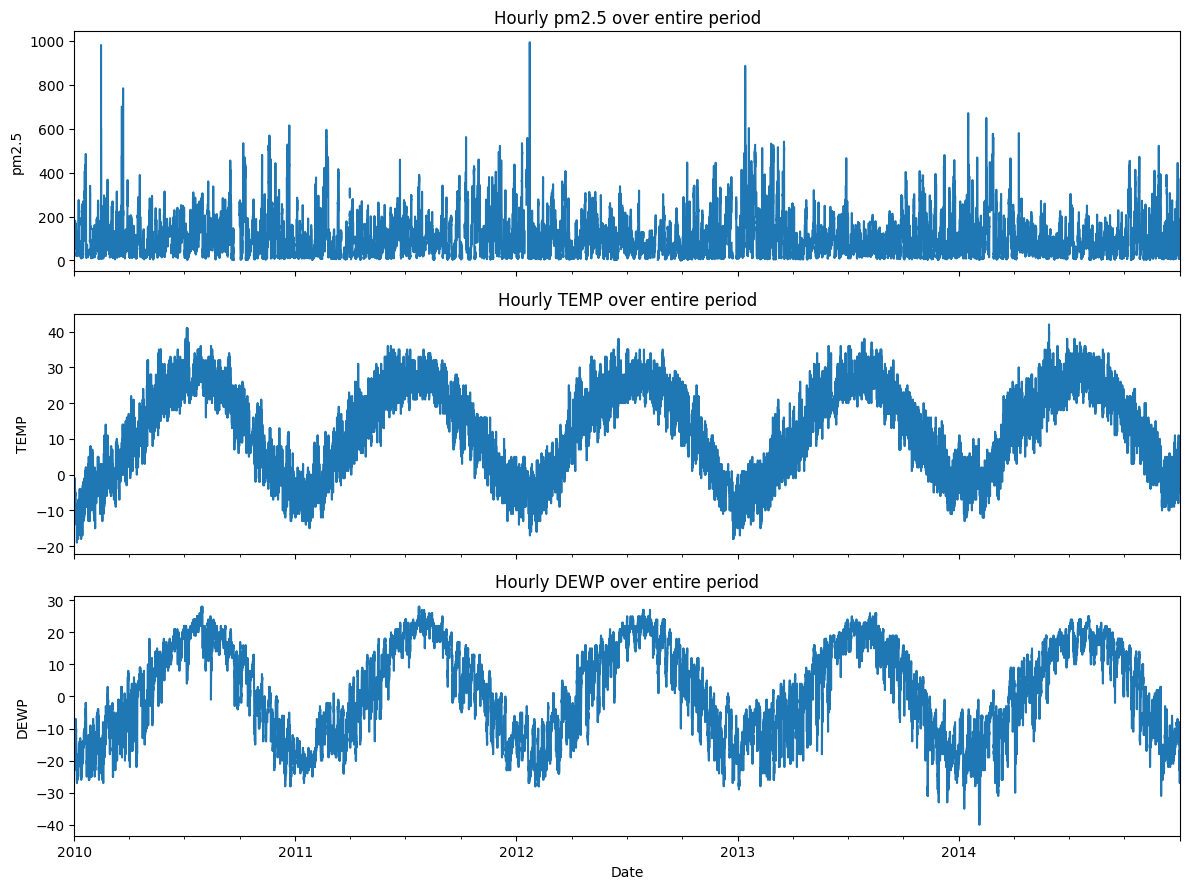

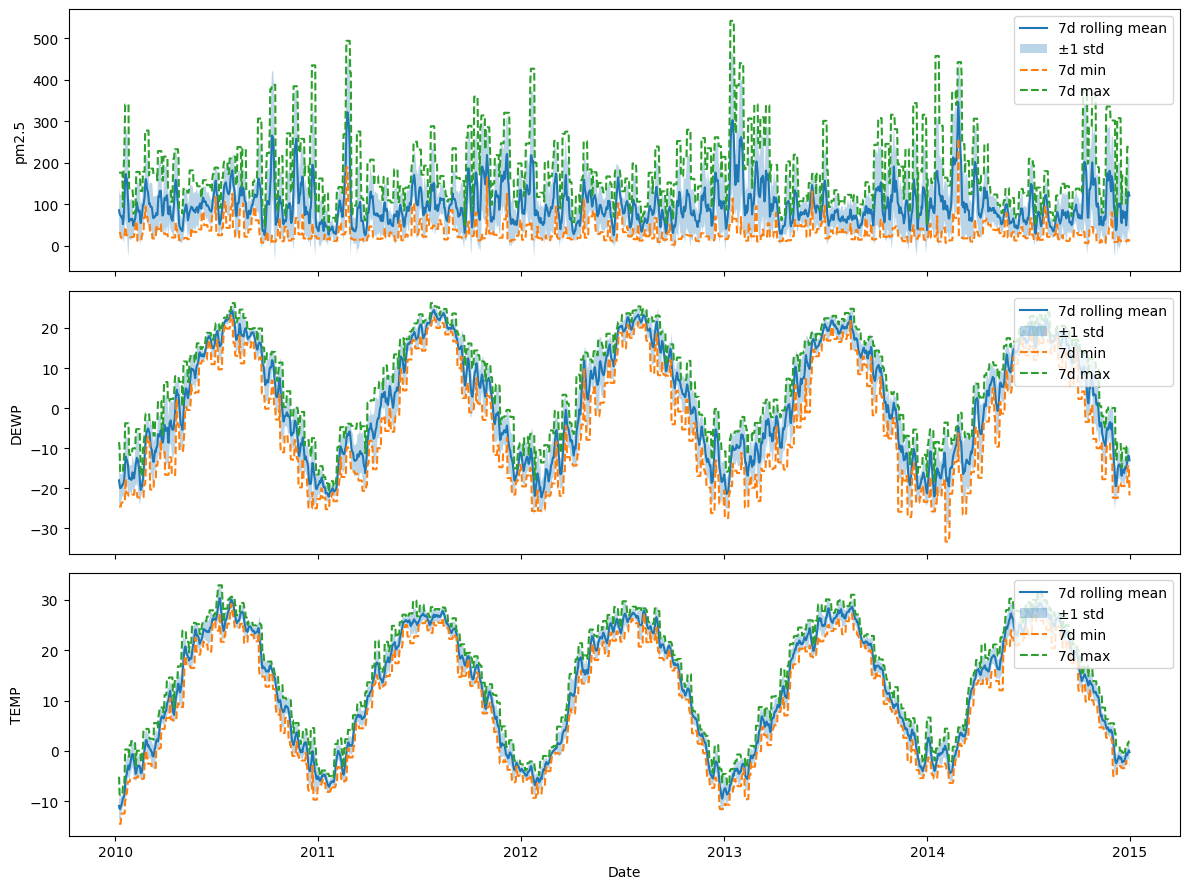

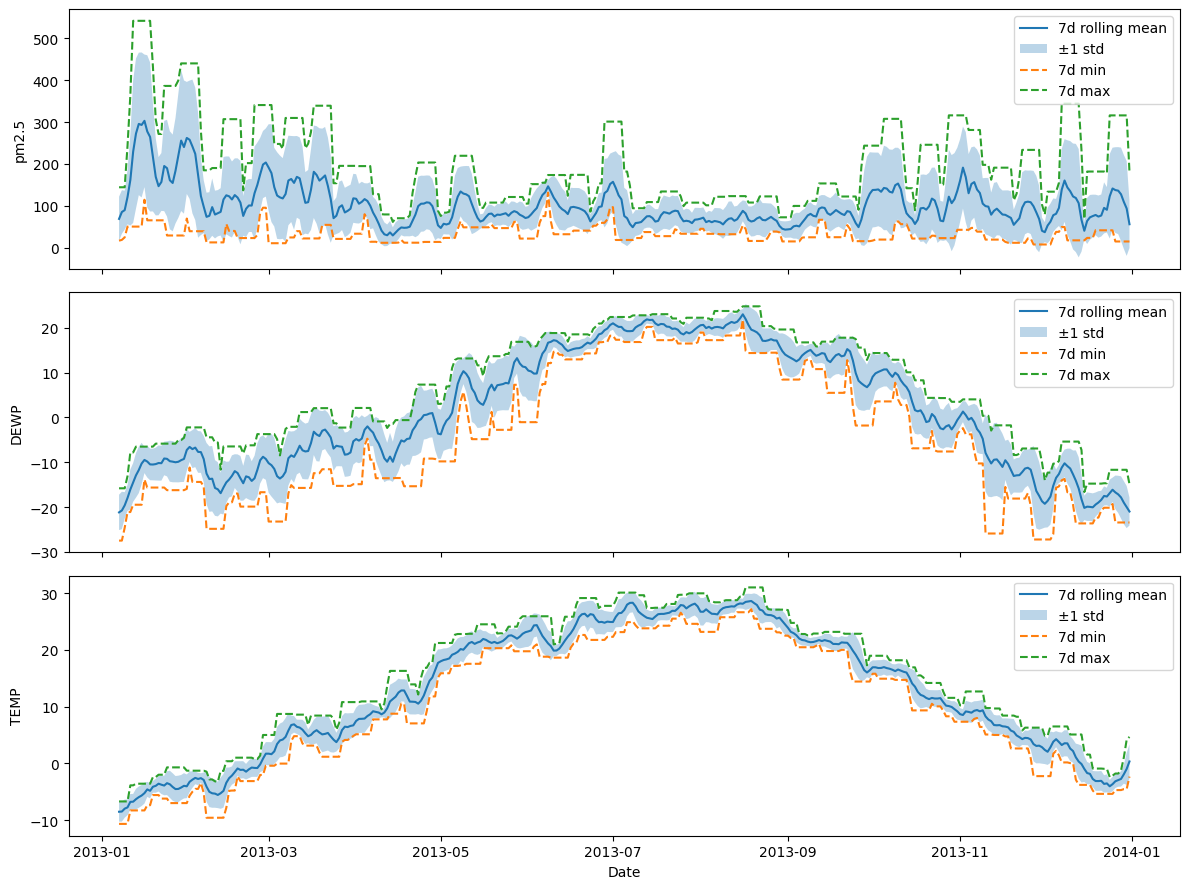

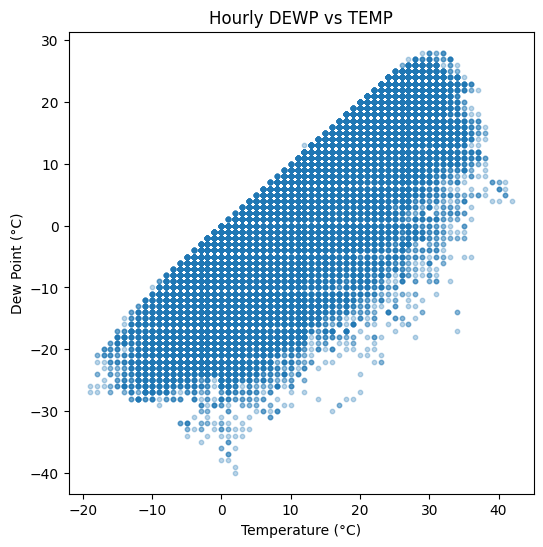

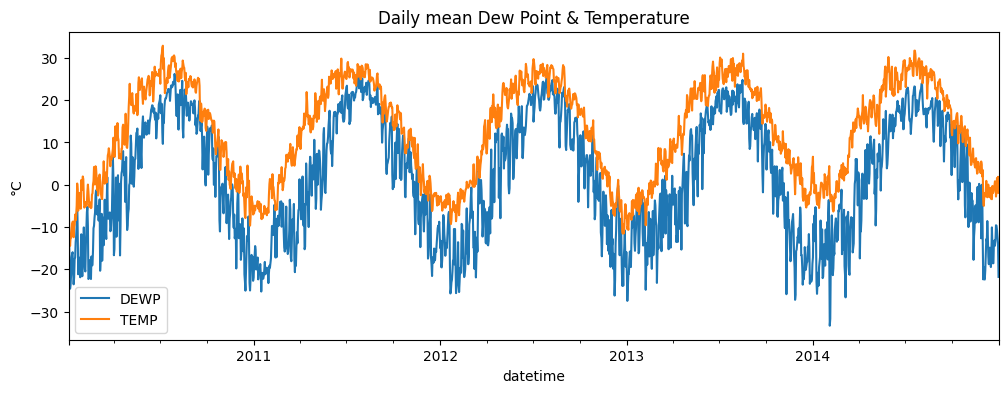

In [5]:
# ---- Raw time series of PM2.5, TEMP & DEWP over the full period ----
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 9))
for ax, col in zip(axes, ['pm2.5', 'TEMP', 'DEWP']):
    df[col].plot(ax=ax, title=f"Hourly {col} over entire period")
    ax.set_ylabel(col)
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


# ---- Handle missing values in pm2.5, DEWP & TEMP ----
# Simple time‐based interpolation for short gaps, then drop leftovers
df[['pm2.5','DEWP','TEMP']] = (
    df[['pm2.5','DEWP','TEMP']]
    .interpolate(method='time')   # fill via linear interpolation on the datetime index
)
df.dropna(subset=['pm2.5','DEWP','TEMP'], inplace=True)

# ---- Rolling statistics on daily data (7-day window) ----
# First, get daily means
daily = df[['pm2.5','DEWP','TEMP']].resample('D').mean()

# Compute rolling stats: mean, std, min, max over a 7-day window
rolling_stats = daily.rolling(window=7).agg(['mean','std','min','max'])

# Plot rolling stats for each variable
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 9))
for ax, col in zip(axes, ['pm2.5', 'DEWP', 'TEMP']):
    stats = rolling_stats[col]
    ax.plot(stats.index, stats['mean'], label='7d rolling mean')
    ax.fill_between(stats.index,
                    stats['mean'] - stats['std'],
                    stats['mean'] + stats['std'],
                    alpha=0.3,
                    label='±1 std')
    ax.plot(stats.index, stats['min'], linestyle='--', label='7d min')
    ax.plot(stats.index, stats['max'], linestyle='--', label='7d max')
    ax.set_ylabel(col)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()


# ---- Same rolling statistics, but zoomed in on 2013 ----
# Use .loc with a date‐range or year string to slice rows, not df['2013']
daily_2013 = daily.loc['2013-01-01':'2013-12-31']

rolling_stats_2013 = (
    daily_2013
    .rolling(window=7)
    .agg(['mean','std','min','max'])
)

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 9))
for ax, col in zip(axes, ['pm2.5', 'DEWP', 'TEMP']):
    stats = rolling_stats_2013[col]
    ax.plot(stats.index, stats['mean'], label='7d rolling mean')
    ax.fill_between(
        stats.index,
        stats['mean'] - stats['std'],
        stats['mean'] + stats['std'],
        alpha=0.3,
        label='±1 std'
    )
    ax.plot(stats.index, stats['min'], linestyle='--', label='7d min')
    ax.plot(stats.index, stats['max'], linestyle='--', label='7d max')
    ax.set_ylabel(col)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()




# ---- DEWP vs TEMP scatter ----
plt.figure(figsize=(6,6))
plt.scatter(df['TEMP'], df['DEWP'], alpha=0.3, s=10)
plt.xlabel("Temperature (°C)")
plt.ylabel("Dew Point (°C)")
plt.title("Hourly DEWP vs TEMP")
plt.show()

# ---- Daily mean DEWP & TEMP over time ----
df[['DEWP','TEMP']].resample('D').mean().plot(
    title="Daily mean Dew Point & Temperature",
    ylabel="°C",
    figsize=(12,4)
)
plt.show()



## 2. Periodicity & Autocorrelation (basic)

We’ll keep it simple:

1. **Seasonal indicators** – pull out month, day-of-week and hour  
2. **Autocorrelation plot** – see how much current PM₂.₅ “remembers” its past  
3. **Frequency features** – sine/cosine for the 24 h cycle



<Figure size 800x400 with 0 Axes>

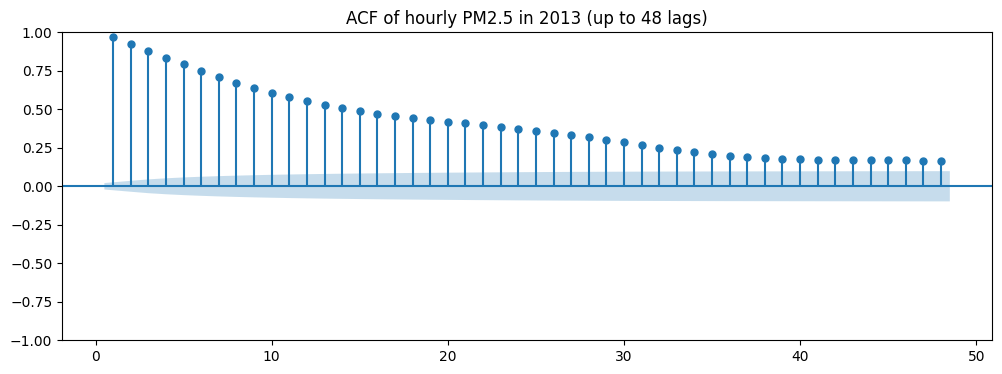

<Figure size 800x400 with 0 Axes>

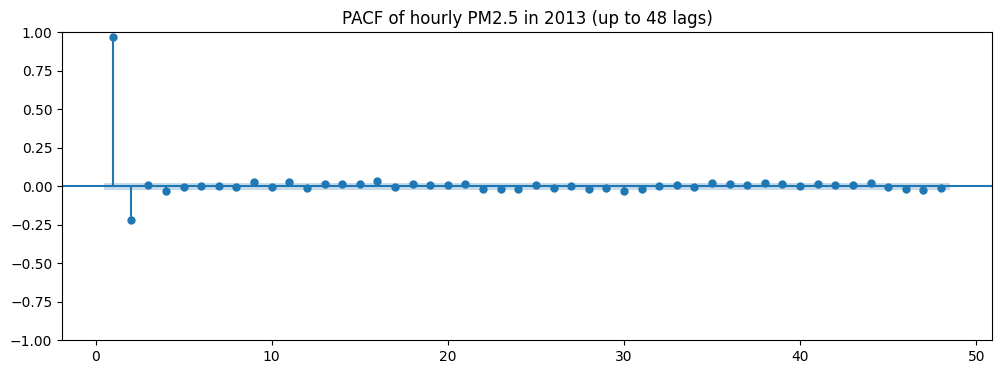

In [6]:
# ---- 1. Seasonal indicators ----
import numpy as np
from pandas.plotting import autocorrelation_plot

# assume df already has a DateTimeIndex and pm2.5 column
df['month']      = df.index.month
df['dayofweek']  = df.index.dayofweek
df['hour']       = df.index.hour

df[['pm2.5','month','dayofweek','hour']].head()

# ---- 2. Periodicity & autocorrelation ----
from pandas.plotting    import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

year = '2013'
df_year = df.loc[f'{year}-01-01':f'{year}-12-31'].copy()

# ---- 2. ACF & PACF for PM2.5 in {year} ----
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(8,4))
plot_acf(df_year['pm2.5'].dropna(), lags=48, zero=False)
plt.title(f"ACF of hourly PM2.5 in {year} (up to 48 lags)")
plt.show()

plt.figure(figsize=(8,4))
plot_pacf(df_year['pm2.5'].dropna(), lags=48, zero=False, method='ywm')
plt.title(f"PACF of hourly PM2.5 in {year} (up to 48 lags)")
plt.show()


In [7]:
# ---- 3. Frequency features (daily cycle) ----
# map hour into a circle so model can learn the 24h cycle smoothly


df['sin_hour'] = np.sin(2*np.pi * df.index.hour / 24)
df['cos_hour'] = np.cos(2*np.pi * df.index.hour / 24)

df[['hour','sin_hour','cos_hour']].head()

,hour,sin_hour,cos_hour
datetime,,,
2010-01-02 00:00:00,0,0.000000,1.000000
2010-01-02 01:00:00,1,0.258819,0.965926
2010-01-02 02:00:00,2,0.500000,0.866025
2010-01-02 03:00:00,3,0.707107,0.707107
2010-01-02 04:00:00,4,0.866025,0.500000


## 4. Feature Importance & Selection

1. **Correlation heatmap** to spot strong linear relationships  
2. **Recursive Feature Elimination (RFE)** with a linear model  
3. **Tree‐based feature importances** from a Random Forest  



In [8]:
import pandas as pd
import numpy as np

# copy and interpolate all numeric columns in place
data = df.copy()
nums = ['pm2.5','DEWP','TEMP','PRES','Iws','Is','Ir']
data[nums] = data[nums].interpolate(method='time')
data.dropna(subset=nums, inplace=True)

# extract simple time features
data['month']     = data.index.month
data['dayofweek'] = data.index.dayofweek
data['hour']      = data.index.hour

# one-hot encode the wind-direc tion category
data = pd.get_dummies(data, columns=['cbwd'], drop_first=True)

# split into X, y
X = data.drop(columns=['pm2.5'])
y = data['pm2.5']

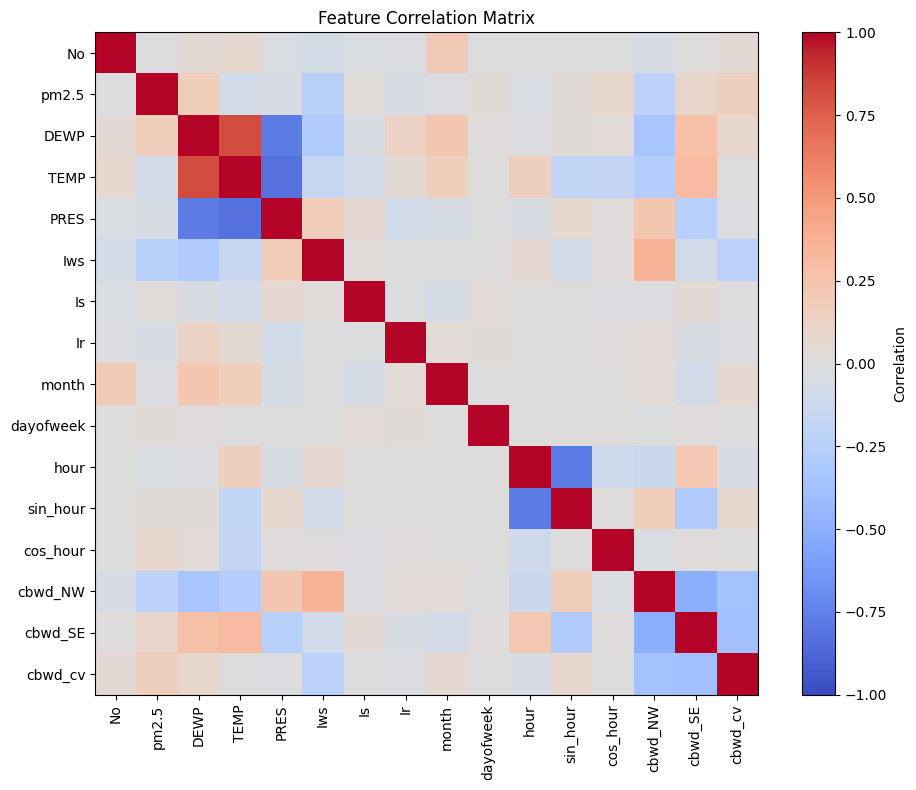

In [9]:
# ---- 1. Correlation heatmap ----
import matplotlib.pyplot as plt

corr = data.corr()
plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


In [10]:
# ---- 2. Recursive Feature Elimination (RFE) ----
from sklearn.feature_selection import RFE
from sklearn.linear_model      import LinearRegression

lr = LinearRegression()
rfe = RFE(lr, n_features_to_select=5, step=1)
rfe.fit(X, y)

selected = X.columns[rfe.support_]
print("Top 5 features selected by RFE:")
for feat in selected:
    print(" ", feat)


Top 5 features selected by RFE:
  sin_hour
  cos_hour
  cbwd_NW
  cbwd_SE
  cbwd_cv


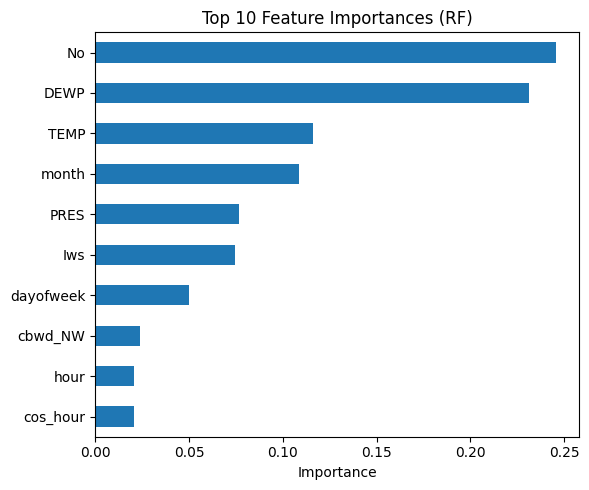

In [11]:
# ---- 3. Random Forest feature importances ----
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

# bar chart
plt.figure(figsize=(6,5))
top10.sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances (RF)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


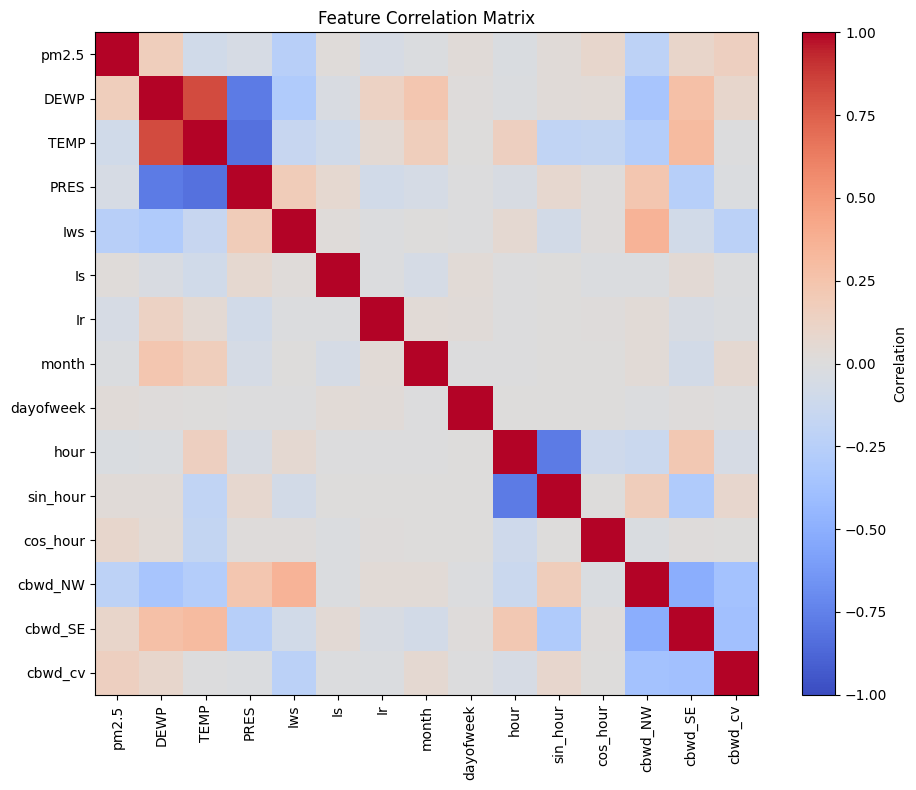

Top 5 features selected by RFE:
   sin_hour
   cos_hour
   cbwd_NW
   cbwd_SE
   cbwd_cv


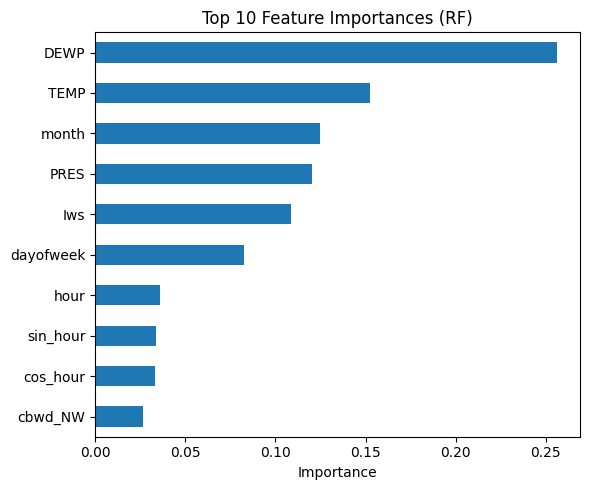

In [12]:
# ---- Unified feature‐importance workflow (drops 'No' column) ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE
from sklearn.linear_model      import LinearRegression
from sklearn.ensemble          import RandomForestRegressor

# 1. Prepare data: drop 'No', interpolate, extract time features, one-hot wind dir
data = df.copy()
if 'No' in data.columns:
    data = data.drop(columns=['No'])

nums = ['pm2.5','DEWP','TEMP','PRES','Iws','Is','Ir']
data[nums] = data[nums].interpolate(method='time')
data = data.dropna(subset=nums)

data['month']     = data.index.month
data['dayofweek'] = data.index.dayofweek
data['hour']      = data.index.hour

data = pd.get_dummies(data, columns=['cbwd'], drop_first=True)

# split into X, y
X = data.drop(columns=['pm2.5'])
y = data['pm2.5']

# ---- 2. Correlation heatmap ----
corr = data.corr()
plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# ---- 3. Recursive Feature Elimination (RFE) ----
lr  = LinearRegression()
rfe = RFE(lr, n_features_to_select=5, step=1).fit(X, y)

print("Top 5 features selected by RFE:")
for feat in X.columns[rfe.support_]:
    print("  ", feat)

# ---- 4. Random Forest feature importances ----
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(6,5))
top10.sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances (RF)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 6. Clustering Analysis on Time Series Data

We’ll use the pre-processed `data` (with interpolated numeric, time‐flags, one-hot wind-dir), scale it, then:

1. **K-Means**  
   - Tune `k` via silhouette score  
   - Fit & assign cluster labels  
2. **DBSCAN**  
   - Try a few `eps` values, pick the best via silhouette  
   - Fit & assign cluster labels  
3. **Visualize**  
   - PM₂.₅ over time colored by cluster  
   - PM₂.₅ distribution by cluster (boxplot)  
4. **Evaluate**  
   - Silhouette Score & Davies-Bouldin for each method  


In [ ]:
# ---- Prepare & scale features ----
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster       import KMeans, DBSCAN
from sklearn.metrics       import silhouette_score, davies_bouldin_score

# assume df already has interpolated nums, time‐flags and one-hot cbwd
data = df.copy()
# drop No if present
data = data.drop(columns=['No'], errors='ignore')

# re-interpolate and rebuild time/features
nums = ['pm2.5','DEWP','TEMP','PRES','Iws','Is','Ir']
data[nums] = data[nums].interpolate(method='time')
data = data.dropna(subset=nums)
data['month'], data['dayofweek'], data['hour'] = \
    data.index.month, data.index.dayofweek, data.index.hour
data = pd.get_dummies(data, columns=['cbwd'], drop_first=True)

X = data.drop(columns=['pm2.5'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ---- KMeans: choose k by silhouette ----
sil_scores = []
K_range = range(2,7)
for k in K_range:
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(list(K_range), sil_scores, marker='o')
plt.xlabel('n_clusters'); plt.ylabel('silhouette score')
plt.title('KMeans silhouette by k'); plt.show()

best_k = K_range[np.argmax(sil_scores)]
print(f"→ Best k = {best_k}")
kmeans = KMeans(n_clusters=best_k, random_state=42).fit(X_scaled)
data['km_cluster'] = kmeans.labels_


# ---- Evaluation metrics ----
# KMeans
km_sil = silhouette_score(X_scaled, data['km_cluster'])
km_db  = davies_bouldin_score(X_scaled, data['km_cluster'])
print(f"KMeans → Silhouette: {km_sil:.3f}, DB index: {km_db:.3f}")

# DBSCAN (exclude noise)
mask = data['db_cluster'] != -1
if len(set(data.loc[mask,'db_cluster']))>1:
    dbs = silhouette_score(X_scaled[mask], data.loc[mask,'db_cluster'])
    dbdb = davies_bouldin_score(X_scaled[mask], data.loc[mask,'db_cluster'])
    print(f"DBSCAN → Silhouette: {dbs:.3f}, DB index: {dbdb:.3f}")
else:
    print("DBSCAN → not enough clusters for silhouette")


# ---- Visualization ----
# 1) PM2.5 over time colored by KMeans
plt.figure(figsize=(12,3))
plt.scatter(data.index, data['pm2.5'], c=data['km_cluster'], s=5, cmap='tab10')
plt.title("PM2.5 over time  (KMeans)"); plt.ylabel("µg/m³"); plt.xlabel("Date"); plt.show()

# 2) PM2.5 over time colored by DBSCAN
plt.figure(figsize=(12,3))
plt.scatter(data.index, data['pm2.5'], c=data['db_cluster'], s=5, cmap='tab10')
plt.title("PM2.5 over time  (DBSCAN)"); plt.ylabel("µg/m³"); plt.xlabel("Date"); plt.show()

# 3) Boxplot of PM2.5 by cluster
for method, col in [('KMeans','km_cluster'),('DBSCAN','db_cluster')]:
    groups = data[data[col]!=-1].groupby(col)['pm2.5']
    plt.figure(figsize=(5,3))
    plt.boxplot([groups.get_group(c) for c in sorted(groups.groups)],
                labels=sorted(groups.groups))
    plt.title(f"PM2.5 by {method} cluster")
    plt.xlabel(f"{method} cluster"); plt.ylabel("PM2.5")
    plt.show()
